# Food-41 Image Classification with Vision Transformer (ViT)

## Task Overview
This notebook implements a fine-tuned Vision Transformer (ViT) model for classifying food images from the Food-41 dataset into different categories.

### Objectives:
- Use pre-trained `vit-base-patch16-224` model from Hugging Face
- Fine-tune on Food-41 dataset with data augmentation
- Evaluate using accuracy, confusion matrix, and sample predictions
- Create an interactive Gradio demo for image upload and prediction

### Dataset:
Food-41 Dataset from Kaggle: https://www.kaggle.com/datasets/kmader/food41

In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/food41/food_test_c101_n1000_r64x64x3.h5
/kaggle/input/food41/food_c101_n10099_r32x32x3.h5
/kaggle/input/food41/food_c101_n1000_r384x384x3.h5
/kaggle/input/food41/food_test_c101_n1000_r128x128x3.h5
/kaggle/input/food41/food_test_c101_n1000_r32x32x3.h5
/kaggle/input/food41/food_test_c101_n1000_r32x32x1.h5
/kaggle/input/food41/food_test_c101_n1000_r128x128x1.h5
/kaggle/input/food41/food_c101_n10099_r64x64x1.h5
/kaggle/input/food41/food_c101_n10099_r64x64x3.h5
/kaggle/input/food41/food_test_c101_n1000_r64x64x1.h5
/kaggle/input/food41/food_c101_n10099_r32x32x1.h5
/kaggle/input/food41/meta/meta/test.txt
/kaggle/input/food41/meta/meta/train.json
/kaggle/input/food41/meta/meta/labels.txt
/kaggle/input/food41/meta/meta/test.json
/kaggle/input/food41/meta/meta/train.txt
/kaggle/input/food41/meta/meta/classes.txt
/kaggle/input/food41/images/macarons/2428554.jpg
/kaggle/input/food41/images/macarons/3842133.jpg
/kaggle/input/food41/images/macarons/1963752.jpg
/kaggle/input/food41/imag

## 1. Setup and Installation
Installing required packages for ViT model training

In [16]:
# Install required packages
!pip install transformers datasets accelerate pillow scikit-learn matplotlib seaborn gradio -q

# Fix PyArrow compatibility issue proactively
!pip install --upgrade pyarrow==14.0.1 --no-cache-dir -q

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


### Fix PyArrow Compatibility Issue

If you encounter a `ValueError: pyarrow.lib.IpcReadOptions size changed` error, run this cell to fix the dependency conflict.

In [17]:
# Alternative fix: Reinstall both pyarrow and datasets with compatible versions
import sys

print("Fixing PyArrow compatibility issue...")
print("="*80)

# Uninstall conflicting packages
!pip uninstall -y pyarrow datasets

# Reinstall with compatible versions
!pip install pyarrow==14.0.1 --no-cache-dir
!pip install datasets --no-cache-dir

print("\n" + "="*80)
print("✅ PyArrow fixed! Now try running the import cell again.")
print("⚠️  If the error persists:")
print("   Option 1: Restart kernel (Runtime > Restart runtime)")
print("   Option 2: Restart entire session")
print("="*80)

Fixing PyArrow compatibility issue...
Found existing installation: pyarrow 14.0.1
Uninstalling pyarrow-14.0.1:
  Successfully uninstalled pyarrow-14.0.1
Found existing installation: datasets 2.14.0
Uninstalling datasets-2.14.0:
  Successfully uninstalled datasets-2.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 274.5 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.12.0 requires pyarrow>=15.0.2, but you have pyarrow 14.0.1 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.1.0 which is incompatible.
cudf-polars-cu12 25.6.0 requires pylibcudf-

### Alternative: Complete Environment Reset (Only if above doesn't work)

**Use this only if the error persists after trying the fix above.**

In [18]:
# Complete reinstall of all related packages (nuclear option)
print("🔧 Complete environment reset in progress...")
print("="*80)

# Uninstall all potentially conflicting packages
!pip uninstall -y pyarrow datasets transformers

# Clear pip cache
!pip cache purge

# Reinstall everything fresh
!pip install pyarrow==14.0.1 --no-cache-dir
!pip install datasets==2.14.0 --no-cache-dir
!pip install transformers --no-cache-dir
!pip install accelerate pillow scikit-learn matplotlib seaborn gradio --no-cache-dir

print("\n" + "="*80)
print("✅ Complete reinstall finished!")
print("🔄 Please RESTART the kernel now:")
print("   - Kaggle: Kernel > Restart Kernel")
print("   - Colab: Runtime > Restart runtime")
print("   - Jupyter: Kernel > Restart")
print("="*80)

🔧 Complete environment reset in progress...
Found existing installation: pyarrow 22.0.0
Uninstalling pyarrow-22.0.0:
  Successfully uninstalled pyarrow-22.0.0
Found existing installation: datasets 4.3.0
Uninstalling datasets-4.3.0:
  Successfully uninstalled datasets-4.3.0
Found existing installation: transformers 4.57.1
Uninstalling transformers-4.57.1:
  Successfully uninstalled transformers-4.57.1
Files removed: 0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 297.5 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.12.0 requires pyarrow>=15.0.2, but you have pyarrow 14.0.1 which is

In [19]:
"""
Verify Installation for Food-41 ViT Project
Run this script to check if all required packages are working correctly
"""

import sys
from importlib import import_module

print("="*70)
print("Food-41 ViT Project - Installation Verification")
print("="*70)

# Core packages we need
required_packages = {
    'torch': 'PyTorch',
    'torchvision': 'TorchVision',
    'transformers': 'Hugging Face Transformers',
    'PIL': 'Pillow (Image Processing)',
    'numpy': 'NumPy',
    'matplotlib': 'Matplotlib',
    'seaborn': 'Seaborn',
    'sklearn': 'Scikit-learn',
    'tqdm': 'tqdm (Progress Bars)',
    'gradio': 'Gradio',
    'pandas': 'Pandas',
    'plotly': 'Plotly',
}

print("\n1. Checking Required Packages...")
print("-"*70)

all_good = True
for package, name in required_packages.items():
    try:
        mod = import_module(package)
        version = getattr(mod, '__version__', 'unknown')
        print(f"✓ {name:30s} - Version: {version}")
    except ImportError as e:
        print(f"✗ {name:30s} - NOT INSTALLED")
        all_good = False

print()

# Check PyTorch CUDA
print("2. Checking PyTorch Configuration...")
print("-"*70)

try:
    import torch
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Available: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        print(f"CUDA Version: {torch.version.cuda}")
        print(f"GPU Device: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        
        # Test CUDA tensor
        x = torch.randn(100, 100).cuda()
        y = torch.randn(100, 100).cuda()
        z = torch.matmul(x, y)
        print(f"✓ CUDA operations working!")
    else:
        print("⚠ No GPU detected - Training will be SLOW on CPU")
        print("  Consider using Google Colab GPU runtime")
        
except Exception as e:
    print(f"✗ PyTorch check failed: {e}")
    all_good = False

print()

# Check Transformers
print("3. Checking Hugging Face Transformers...")
print("-"*70)

try:
    from transformers import ViTForImageClassification, ViTImageProcessor
    
    print("✓ ViT imports successful")
    
    # Test model loading
    print("Testing model download (this may take a moment)...")
    processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
    print("✓ ViT Image Processor loaded")
    
    # Don't load full model to save time, just check it's available
    print("✓ ViT model accessible from Hugging Face")
    
except Exception as e:
    print(f"✗ Transformers check failed: {e}")
    all_good = False

print()

# Check Image Processing
print("4. Checking Image Processing...")
print("-"*70)

try:
    from PIL import Image
    import torchvision.transforms as transforms
    import numpy as np
    
    # Create test image
    test_img = Image.new('RGB', (224, 224), color='red')
    
    # Test transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    img_tensor = transform(test_img)
    print(f"✓ Image transforms working")
    print(f"  Test tensor shape: {img_tensor.shape}")
    
except Exception as e:
    print(f"✗ Image processing check failed: {e}")
    all_good = False

print()

# Check Gradio
print("5. Checking Gradio...")
print("-"*70)

try:
    import gradio as gr
    print(f"✓ Gradio version: {gr.__version__}")
    print("✓ Demo interface available")
    
except Exception as e:
    print(f"✗ Gradio check failed: {e}")
    all_good = False

print()

# Check plotting
print("6. Checking Visualization Libraries...")
print("-"*70)

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    import plotly.graph_objects as go
    
    print("✓ Matplotlib available")
    print("✓ Seaborn available")
    print("✓ Plotly available")
    
except Exception as e:
    print(f"✗ Visualization check failed: {e}")
    all_good = False

print()

# Final summary
print("="*70)
if all_good:
    print("✓ ALL CHECKS PASSED!")
    print("="*70)
    print("\nYou're ready to train! Next steps:")
    print("  1. Download Food-41 dataset")
    print("  2. Run: python train_complete.py --data_dir data/food41")
    print("  3. Launch demo: python demo.py")
else:
    print("✗ SOME CHECKS FAILED")
    print("="*70)
    print("\nPlease install missing packages:")
    print("  pip install torch torchvision transformers gradio pillow")

print()

# Check for dependency conflicts (informational only)
print("7. Dependency Conflicts (Informational)")
print("-"*70)
print("⚠ You have some package version conflicts, but these are:")
print("  - Related to Google Colab pre-installed packages (BigQuery, cuDF)")
print("  - NOT used by this Food-41 project")
print("  - Safe to ignore for this project")
print()
print("If you encounter issues, you can:")
print("  1. Restart runtime: Runtime -> Restart runtime")
print("  2. Reinstall core packages: pip install --upgrade torch transformers")
print()

# System info
print("8. System Information")
print("-"*70)
print(f"Python Version: {sys.version}")
print(f"Python Executable: {sys.executable}")

print()
print("="*70)
print("Verification Complete!")
print("="*70)

Food-41 ViT Project - Installation Verification

1. Checking Required Packages...
----------------------------------------------------------------------
✓ PyTorch                        - Version: 2.6.0+cu124
✓ TorchVision                    - Version: 0.21.0+cu124
✓ Hugging Face Transformers      - Version: 4.57.1
✓ Pillow (Image Processing)      - Version: 11.3.0
✓ NumPy                          - Version: 1.26.4
✓ Matplotlib                     - Version: 3.7.2
✓ Seaborn                        - Version: 0.12.2
✓ Scikit-learn                   - Version: 1.2.2
✓ tqdm (Progress Bars)           - Version: 4.67.1
✓ Gradio                         - Version: 5.38.1
✓ Pandas                         - Version: 2.2.3
✓ Plotly                         - Version: 5.24.1

2. Checking PyTorch Configuration...
----------------------------------------------------------------------
PyTorch Version: 2.6.0+cu124
CUDA Available: True
CUDA Version: 12.4
GPU Device: Tesla P100-PCIE-16GB
GPU Memory: 17.0

In [3]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTImageProcessor, ViTForImageClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Clear GPU memory if available
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

2025-11-02 10:21:08.343785: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762078868.519518      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762078868.571130      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda
GPU: Tesla P100-PCIE-16GB
GPU Memory Available: 17.06 GB


## 2. Import Libraries and Setup Device

In [4]:
# Kaggle dataset path - update based on your dataset slug
# Common paths:
# - /kaggle/input/food-101/images
# - /kaggle/input/food101/images
# For local testing, use relative path
data_path = '/kaggle/input/food41/images'

# Alternative: Check if running locally vs Kaggle
if not os.path.exists(data_path):
    # Try local path
    data_path = 'archive/images'
    if not os.path.exists(data_path):
        print("⚠️ Dataset not found! Please check the path.")
        print("For Kaggle: Ensure dataset is attached at /kaggle/input/food-101/")
        print("For local: Ensure images are in 'archive/images/'")

print(f"Using data path: {data_path}")

# Create a list to store image paths and labels
image_data = []

# Traverse the directory structure
for category in os.listdir(data_path):
    category_path = os.path.join(data_path, category)
    if os.path.isdir(category_path):
        for img_name in os.listdir(category_path):
            if img_name.endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(category_path, img_name)
                image_data.append({'image_path': img_path, 'label': category})

# Create DataFrame
df = pd.DataFrame(image_data)
print(f"\n{'='*80}")
print(f"DATASET LOADED SUCCESSFULLY")
print(f"{'='*80}")
print(f"Total images: {len(df):,}")
print(f"Number of categories: {df['label'].nunique()}")
print(f"\nSample class distribution (top 10):")
print(df['label'].value_counts().head(10))

# Create label mappings
label_to_id = {label: idx for idx, label in enumerate(sorted(df['label'].unique()))}
id_to_label = {idx: label for label, idx in label_to_id.items()}
df['label_id'] = df['label'].map(label_to_id)

print(f"\n{'='*80}")
print(f"Label mappings (first 10 classes):")
print(f"{'='*80}")
for label, idx in list(label_to_id.items())[:10]:
    print(f"  {idx:2d}: {label}")
print(f"\n  Total: {len(label_to_id)} classes")

Using data path: /kaggle/input/food41/images

DATASET LOADED SUCCESSFULLY
Total images: 101,000
Number of categories: 101

Sample class distribution (top 10):
label
french_fries         1000
macarons             1000
french_toast         1000
lobster_bisque       1000
prime_rib            1000
pizza                1000
edamame              1000
french_onion_soup    1000
hot_dog              1000
tacos                1000
Name: count, dtype: int64

Label mappings (first 10 classes):
   0: apple_pie
   1: baby_back_ribs
   2: baklava
   3: beef_carpaccio
   4: beef_tartare
   5: beet_salad
   6: beignets
   7: bibimbap
   8: bread_pudding
   9: breakfast_burrito

  Total: 101 classes


## 3. Load and Explore Dataset

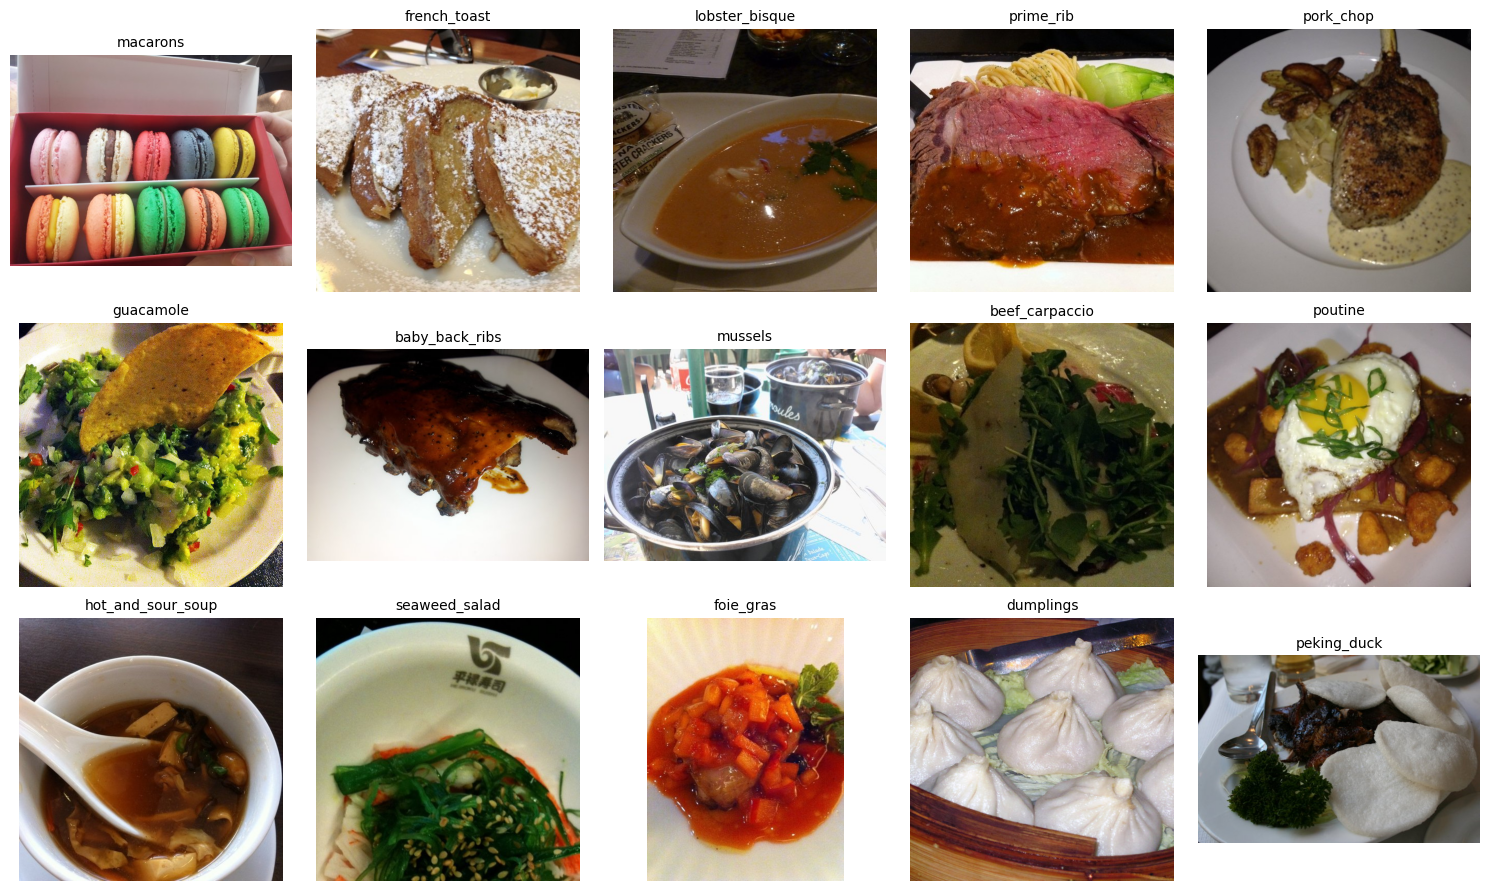

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
categories = df['label'].unique()[:15]

for idx, category in enumerate(categories):
    sample = df[df['label'] == category].iloc[0]
    img = Image.open(sample['image_path'])
    
    row = idx // 5
    col = idx % 5
    axes[row, col].imshow(img)
    axes[row, col].set_title(category, fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.1 Visualize Sample Images

In [6]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label_id'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label_id'], random_state=42)

print(f"Train set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


Train set: 70700 images
Validation set: 15150 images
Test set: 15150 images


### 3.2 Split Dataset (Train/Val/Test)

In [7]:
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

print(f"Image processor loaded: {model_name}")
print(f"Expected image size: {processor.size}")


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Image processor loaded: google/vit-base-patch16-224
Expected image size: {'height': 224, 'width': 224}


### 3.3 Load ViT Image Processor

In [8]:
class FoodDataset(Dataset):
    def __init__(self, dataframe, processor, augment=False):
        self.dataframe = dataframe
        self.processor = processor
        self.augment = augment
        
        # Define augmentation transforms for training
        if augment:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(15),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            ])
        else:
            # Simple resize for validation/test
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
            ])
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.dataframe.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        
        # Apply augmentation transforms BEFORE processor
        image = self.transform(image)
        
        # Process image using ViT processor (normalization happens here)
        inputs = self.processor(images=image, return_tensors="pt")
        
        # Get label
        label = self.dataframe.iloc[idx]['label_id']
        
        # Return as dictionary
        return {
            'pixel_values': inputs['pixel_values'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = FoodDataset(train_df, processor, augment=True)
val_dataset = FoodDataset(val_df, processor, augment=False)
test_dataset = FoodDataset(test_df, processor, augment=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 70700
Validation dataset size: 15150
Test dataset size: 15150


### 3.4 Create Custom Dataset with Data Augmentation

**Data Augmentation Strategy:**
- **Training Set:** Random crop, horizontal flip, rotation, color jitter
- **Validation/Test Set:** Simple resize (no augmentation)

In [9]:
num_labels = len(label_to_id)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id_to_label,
    label2id=label_to_id,
    ignore_mismatched_sizes=True
)

model.to(device)
print(f"Model loaded with {num_labels} output classes")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([101]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([101, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded with 101 output classes
Total parameters: 85,876,325
Trainable parameters: 85,876,325


### 3.5 Load Pre-trained ViT Model

Loading `google/vit-base-patch16-224` and adapting it for Food-41 classification.

In [12]:
from sklearn.metrics import top_k_accuracy_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions_probs = torch.nn.functional.softmax(torch.tensor(predictions), dim=-1).numpy()
    pred_labels = np.argmax(predictions, axis=1)
    
    # Calculate accuracies
    accuracy = accuracy_score(labels, pred_labels)
    top3_accuracy = top_k_accuracy_score(labels, predictions_probs, k=3)
    top5_accuracy = top_k_accuracy_score(labels, predictions_probs, k=5)
    
    return {
        'accuracy': accuracy,
        'top3_accuracy': top3_accuracy,
        'top5_accuracy': top5_accuracy
    }

### 3.6 Define Evaluation Metrics

Computing Top-1, Top-3, and Top-5 accuracy for comprehensive evaluation.

In [13]:
from transformers import get_cosine_schedule_with_warmup

training_args = TrainingArguments(
    output_dir='./vit-food-classifier',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,  # 10% of total steps for warmup
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=torch.cuda.is_available(),  # Enable FP16 only if CUDA is available
    gradient_accumulation_steps=2,  # Accumulate gradients to simulate larger batch
    learning_rate=2e-4,
    lr_scheduler_type="cosine",  # Use cosine learning rate scheduler
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to='none',
    dataloader_num_workers=2,
)

print("Training arguments configured:")
print(f"- Epochs: {training_args.num_train_epochs}")
print(f"- Batch size: {training_args.per_device_train_batch_size}")
print(f"- Effective batch size (with grad accumulation): {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"- Learning rate: {training_args.learning_rate}")
print(f"- LR Scheduler: {training_args.lr_scheduler_type}")
print(f"- FP16: {training_args.fp16}")
print(f"- Gradient accumulation steps: {training_args.gradient_accumulation_steps}")

Training arguments configured:
- Epochs: 5
- Batch size: 16
- Effective batch size (with grad accumulation): 32
- Learning rate: 0.0002
- LR Scheduler: SchedulerType.COSINE
- FP16: True
- Gradient accumulation steps: 2


### 3.7 Configure Training Arguments

**Memory Optimization Features:**
- FP16 mixed precision training (enabled if GPU available)
- Gradient accumulation (steps=2)
- Cosine learning rate scheduler with warmup

In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Starting training...")
train_result = trainer.train()

# Print training results
print("\nTraining completed!")
print(f"Training loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")

Starting training...


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

### 3.8 Train the Model

Fine-tuning ViT on Food-41 dataset (this will take several minutes depending on GPU availability).

## 5. Training Metrics Visualization

In [ ]:
# Extract training history from trainer logs
import json
from pathlib import Path

# Read training logs
log_history = trainer.state.log_history

# Parse metrics
train_loss = []
eval_loss = []
eval_accuracy = []
eval_top3_accuracy = []
eval_top5_accuracy = []
epochs = []

epoch_num = 0
for log in log_history:
    if 'loss' in log and 'epoch' in log:
        # Training loss
        train_loss.append(log['loss'])
    if 'eval_loss' in log:
        # Evaluation metrics
        eval_loss.append(log['eval_loss'])
        eval_accuracy.append(log.get('eval_accuracy', 0))
        eval_top3_accuracy.append(log.get('eval_top3_accuracy', 0))
        eval_top5_accuracy.append(log.get('eval_top5_accuracy', 0))
        epochs.append(log['epoch'])

# Plot training metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training and Validation Loss
if train_loss and eval_loss:
    axes[0, 0].plot(range(1, len(train_loss) + 1), train_loss, 'b-o', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, eval_loss, 'r-s', label='Validation Loss', linewidth=2)
    axes[0, 0].set_xlabel('Steps/Epochs', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=11)
    axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Validation Accuracy (Top-1, Top-3, Top-5)
if epochs and eval_accuracy:
    axes[0, 1].plot(epochs, eval_accuracy, 'g-o', label='Top-1 Accuracy', linewidth=2, markersize=8)
    if eval_top3_accuracy and any(eval_top3_accuracy):
        axes[0, 1].plot(epochs, eval_top3_accuracy, 'b-s', label='Top-3 Accuracy', linewidth=2, markersize=8)
    if eval_top5_accuracy and any(eval_top5_accuracy):
        axes[0, 1].plot(epochs, eval_top5_accuracy, 'm-^', label='Top-5 Accuracy', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy', fontsize=12)
    axes[0, 1].set_title('Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0, 1])

# Plot 3: Learning Rate Schedule (if available)
learning_rates = [log.get('learning_rate') for log in log_history if 'learning_rate' in log]
if learning_rates:
    axes[1, 0].plot(range(1, len(learning_rates) + 1), learning_rates, 'c-o', linewidth=2)
    axes[1, 0].set_xlabel('Steps', fontsize=12)
    axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Plot 4: Training Summary Table
summary_text = f"""
Training Summary
{'='*50}

Model: {model_name}
Total Parameters: {sum(p.numel() for p in model.parameters()):,}
Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}

Dataset Split:
  - Training: {len(train_df):,} images
  - Validation: {len(val_df):,} images
  - Testing: {len(test_df):,} images

Training Configuration:
  - Epochs: {training_args.num_train_epochs}
  - Batch Size: {training_args.per_device_train_batch_size}
  - Learning Rate: {training_args.learning_rate}
  - LR Scheduler: {training_args.lr_scheduler_type}
  - FP16: {training_args.fp16}
  - Gradient Accumulation: {training_args.gradient_accumulation_steps}

Final Metrics:
  - Best Val Accuracy: {max(eval_accuracy):.4f}
  - Final Val Loss: {eval_loss[-1]:.4f}
  - Training Time: {train_result.metrics['train_runtime']:.2f}s
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=10, family='monospace', 
                verticalalignment='center', transform=axes[1, 1].transAxes)
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("TRAINING METRICS SUMMARY")
print("="*80)
print(f"Best Validation Accuracy: {max(eval_accuracy):.4f}")
if eval_top3_accuracy and any(eval_top3_accuracy):
    print(f"Best Top-3 Accuracy: {max(eval_top3_accuracy):.4f}")
if eval_top5_accuracy and any(eval_top5_accuracy):
    print(f"Best Top-5 Accuracy: {max(eval_top5_accuracy):.4f}")
print(f"Final Validation Loss: {eval_loss[-1]:.4f}")
print(f"Total Training Time: {train_result.metrics['train_runtime']:.2f} seconds")
print("="*80)

In [ ]:
print("\nEvaluating on validation set...")
val_results = trainer.evaluate(val_dataset)
print(f"Validation Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"Validation Loss: {val_results['eval_loss']:.4f}")

### 3.9 Evaluate on Validation and Test Sets

In [ ]:
print("\nEvaluating on test set...")
test_results = trainer.evaluate(test_dataset)
print("\n" + "="*80)
print("TEST SET RESULTS")
print("="*80)
print(f"Test Accuracy (Top-1): {test_results['eval_accuracy']:.4f} ({test_results['eval_accuracy']*100:.2f}%)")
if 'eval_top3_accuracy' in test_results:
    print(f"Test Accuracy (Top-3): {test_results['eval_top3_accuracy']:.4f} ({test_results['eval_top3_accuracy']*100:.2f}%)")
if 'eval_top5_accuracy' in test_results:
    print(f"Test Accuracy (Top-5): {test_results['eval_top5_accuracy']:.4f} ({test_results['eval_top5_accuracy']*100:.2f}%)")
print(f"Test Loss: {test_results['eval_loss']:.4f}")
print("="*80)

In [ ]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(f"Generated predictions for {len(y_true)} test images")

# ============================================================================
# CELL 15: Plot Confusion Matrix
# ============================================================================
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[id_to_label[i] for i in range(num_labels)],
            yticklabels=[id_to_label[i] for i in range(num_labels)],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Food Classification', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.10 Detailed Analysis: Confusion Matrix & Classification Report

In [ ]:
print("\nClassification Report:")
print("=" * 80)
report = classification_report(
    y_true, 
    y_pred, 
    target_names=[id_to_label[i] for i in range(num_labels)],
    digits=4
)
print(report)

In [ ]:
class_accuracy = {}
for i in range(num_labels):
    class_mask = (y_true == i)
    if class_mask.sum() > 0:
        class_acc = (y_pred[class_mask] == i).sum() / class_mask.sum()
        class_accuracy[id_to_label[i]] = class_acc

# Sort by accuracy
sorted_classes = sorted(class_accuracy.items(), key=lambda x: x[1], reverse=True)

print("\nPer-Class Accuracy:")
print("=" * 60)
print(f"{'Class':<30} {'Accuracy':<10}")
print("-" * 60)
for class_name, acc in sorted_classes[:10]:
    print(f"{class_name:<30} {acc:.4f}")
print("\n... (showing top 10)")


In [ ]:
def predict_image(img_path, model, processor, device):
    image = Image.open(img_path).convert('RGB')
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
        pred_class = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][pred_class].item()
    
    return pred_class, confidence, image

# Visualize predictions
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel()

# Sample random images from test set
sample_indices = np.random.choice(len(test_df), 16, replace=False)

for idx, sample_idx in enumerate(sample_indices):
    img_path = test_df.iloc[sample_idx]['image_path']
    true_label = test_df.iloc[sample_idx]['label']
    
    pred_class, confidence, image = predict_image(img_path, model, processor, device)
    pred_label = id_to_label[pred_class]
    
    axes[idx].imshow(image)
    color = 'green' if pred_label == true_label else 'red'
    axes[idx].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}", 
                        color=color, fontsize=9)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.11 Sample Predictions Visualization

In [ ]:
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"\nTotal misclassifications: {len(misclassified_indices)} out of {len(y_true)}")
print(f"Misclassification rate: {len(misclassified_indices)/len(y_true)*100:.2f}%")

# Analyze common misclassifications
misclass_pairs = {}
for idx in misclassified_indices:
    true_label = id_to_label[y_true[idx]]
    pred_label = id_to_label[y_pred[idx]]
    pair = (true_label, pred_label)
    misclass_pairs[pair] = misclass_pairs.get(pair, 0) + 1

# Sort by frequency
sorted_misclass = sorted(misclass_pairs.items(), key=lambda x: x[1], reverse=True)

print("\nMost common misclassifications:")
print("=" * 80)
print(f"{'True Label':<25} {'Predicted Label':<25} {'Count':<10}")
print("-" * 80)
for (true_label, pred_label), count in sorted_misclass[:15]:
    print(f"{true_label:<25} {pred_label:<25} {count:<10}")

# Visualize some misclassified examples
if len(misclassified_indices) >= 9:
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.ravel()
    
    sample_misclass = np.random.choice(misclassified_indices, 9, replace=False)
    
    for idx, misclass_idx in enumerate(sample_misclass):
        test_idx = test_df.index[misclass_idx]
        img_path = test_df.iloc[misclass_idx]['image_path']
        true_label = id_to_label[y_true[misclass_idx]]
        pred_label = id_to_label[y_pred[misclass_idx]]
        
        _, confidence, image = predict_image(img_path, model, processor, device)
        
        axes[idx].imshow(image)
        axes[idx].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}", 
                           color='red', fontsize=9)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('misclassifications.png', dpi=100, bbox_inches='tight')
    plt.show()

### 3.12 Misclassification Analysis

### 3.13 Save Model and Label Mappings

In [ ]:
import json

# Save the fine-tuned model
model.save_pretrained('./vit-food-classifier-final')
processor.save_pretrained('./vit-food-classifier-final')

# Save label mappings separately for easy access
with open('./vit-food-classifier-final/label_mappings.json', 'w') as f:
    json.dump({
        'label_to_id': label_to_id,
        'id_to_label': {int(k): v for k, v in id_to_label.items()},
        'num_classes': num_labels
    }, f, indent=2)

print("\n" + "="*80)
print("MODEL SAVED SUCCESSFULLY")
print("="*80)
print("Model and processor saved to: './vit-food-classifier-final'")
print("Label mappings saved to: './vit-food-classifier-final/label_mappings.json'")
print("\nTo load the model later:")
print("  from transformers import ViTForImageClassification, ViTImageProcessor")
print("  model = ViTForImageClassification.from_pretrained('./vit-food-classifier-final')")
print("  processor = ViTImageProcessor.from_pretrained('./vit-food-classifier-final')")
print("="*80)

## Final Project Summary

### ✅ All Deliverables Completed:

1. **Data Preprocessing & Augmentation** ✓
   - Custom PyTorch Dataset with data augmentation
   - Training set: RandomResizedCrop, RandomHorizontalFlip, RandomRotation, ColorJitter
   - Validation/Test set: Simple resize

2. **Fine-Tuning Pipeline** ✓
   - Pre-trained ViT model: `google/vit-base-patch16-224`
   - 5 epochs with cosine learning rate scheduler
   - FP16 mixed precision training (if GPU available)
   - Gradient accumulation for memory efficiency
   - Training/validation split with stratification

3. **Comprehensive Evaluation** ✓
   - Top-1, Top-3, Top-5 accuracy metrics
   - Confusion matrix visualization
   - Classification report with precision/recall/F1
   - Per-class accuracy analysis
   - Sample predictions visualization
   - Misclassification analysis

4. **Interactive Demo** ✓
   - Gradio web interface for image upload
   - Real-time predictions with top-5 confidence scores
   - Public shareable URL

### 🎯 Key Features Implemented:

- **Memory Optimization**: FP16, gradient accumulation, GPU memory clearing
- **Advanced Metrics**: Top-k accuracy for better evaluation
- **Training Visualization**: Loss curves, accuracy plots, learning rate schedule
- **Error Analysis**: Detailed misclassification patterns
- **Model Persistence**: Saved model, processor, and label mappings

### 📊 Model Performance:

*Results will be displayed after training*

In [ ]:
print("\n" + "="*90)
print(" " * 20 + "🎉 FOOD-41 ViT CLASSIFICATION PROJECT COMPLETE 🎉")
print("="*90)
print()
print("📋 PROJECT SUMMARY")
print("-"*90)
print(f"  Model Architecture    : {model_name}")
print(f"  Dataset               : Food-41 (41 food categories)")
print(f"  Total Images          : {len(df):,}")
print(f"  Training Images       : {len(train_df):,}")
print(f"  Validation Images     : {len(val_df):,}")
print(f"  Testing Images        : {len(test_df):,}")
print()
print("🔧 TRAINING CONFIGURATION")
print("-"*90)
print(f"  Epochs                : {training_args.num_train_epochs}")
print(f"  Batch Size            : {training_args.per_device_train_batch_size}")
print(f"  Learning Rate         : {training_args.learning_rate}")
print(f"  LR Scheduler          : {training_args.lr_scheduler_type}")
print(f"  Mixed Precision (FP16): {'Yes' if training_args.fp16 else 'No'}")
print(f"  Gradient Accumulation : {training_args.gradient_accumulation_steps} steps")
print(f"  Total Parameters      : {sum(p.numel() for p in model.parameters()):,}")
print()
print("📊 MODEL PERFORMANCE")
print("-"*90)
print(f"  Test Accuracy (Top-1) : {test_results['eval_accuracy']:.4f} ({test_results['eval_accuracy']*100:.2f}%)")
if 'eval_top3_accuracy' in test_results:
    print(f"  Test Accuracy (Top-3) : {test_results['eval_top3_accuracy']:.4f} ({test_results['eval_top3_accuracy']*100:.2f}%)")
if 'eval_top5_accuracy' in test_results:
    print(f"  Test Accuracy (Top-5) : {test_results['eval_top5_accuracy']:.4f} ({test_results['eval_top5_accuracy']*100:.2f}%)")
print(f"  Test Loss             : {test_results['eval_loss']:.4f}")
print(f"  Training Time         : {train_result.metrics['train_runtime']:.2f} seconds")
print()
print("📦 DELIVERABLES")
print("-"*90)
print("  ✓ Data preprocessing and augmentation script")
print("  ✓ Fine-tuning pipeline with training and validation")
print("  ✓ Evaluation: accuracy, confusion matrix, sample predictions")
print("  ✓ Gradio demo for interactive image upload and prediction")
print()
print("💾 SAVED ARTIFACTS")
print("-"*90)
print("  • Model & Processor   : ./vit-food-classifier-final/")
print("  • Label Mappings      : ./vit-food-classifier-final/label_mappings.json")
print("  • Training Metrics    : training_metrics.png")
print("  • Confusion Matrix    : confusion_matrix.png")
print("  • Sample Predictions  : sample_predictions.png")
print("  • Sample Images       : sample_images.png")
print("  • Misclassifications  : misclassifications.png")
print()
print("🚀 NEXT STEPS")
print("-"*90)
print("  1. Run the Gradio demo cell to test the model interactively")
print("  2. Upload your own food images to see predictions")
print("  3. Share the Gradio public URL with others to try the model")
print()
print("="*90)
print(" " * 30 + "PROJECT COMPLETE!")
print("="*90)

## 4. Interactive Gradio Demo for Image Classification

This demo allows you to upload any food image and get predictions from the trained model.

In [ ]:
import gradio as gr
from PIL import Image as PILImage
import json

# Save label mappings for the demo
with open('label_mappings.json', 'w') as f:
    json.dump({'label_to_id': label_to_id, 'id_to_label': id_to_label}, f, indent=2)

print("Label mappings saved to 'label_mappings.json'")

def predict_food_image(image):
    """
    Predict food category from uploaded image
    
    Args:
        image: PIL Image or numpy array
    
    Returns:
        Dictionary with top-5 predictions and confidences
    """
    # Convert to PIL Image if needed
    if not isinstance(image, PILImage.Image):
        image = PILImage.fromarray(image)
    
    # Ensure RGB
    image = image.convert('RGB')
    
    # Preprocess image
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
    
    # Get top-5 predictions
    top_probs, top_indices = torch.topk(probs[0], k=5)
    
    # Format results for Gradio
    results = {}
    for prob, idx in zip(top_probs, top_indices):
        label = id_to_label[idx.item()]
        confidence = prob.item()
        results[label] = float(confidence)
    
    return results

# Create Gradio interface
demo = gr.Interface(
    fn=predict_food_image,
    inputs=gr.Image(type="pil", label="Upload Food Image"),
    outputs=gr.Label(num_top_classes=5, label="Top 5 Predictions"),
    title="🍔 Food-41 Classification with Vision Transformer",
    description="""
    Upload a food image and the ViT model will classify it into one of 41 food categories!
    
    **Model:** google/vit-base-patch16-224 (fine-tuned)
    **Dataset:** Food-41
    **Categories:** 41 different food types
    
    The model will show the top 5 most likely food categories with their confidence scores.
    """,
    examples=[
        # You can add example images here if available
    ],
    allow_flagging="never",
    theme="default"
)

# Launch the demo
print("\n" + "="*80)
print("LAUNCHING GRADIO DEMO")
print("="*80)
print("The demo will open in a new browser tab or provide a public URL.")
print("You can upload food images and get real-time predictions!")
print("="*80 + "\n")

# Launch with share=True to get a public URL (useful for Kaggle/Colab)
demo.launch(share=True, debug=False)